<a href="https://colab.research.google.com/github/Ahmad-Alfin/Klasifikasi-Penyakit-Daun-Kopi-Arsitektur-EfficientNetV2-dengan-Modul-Atensi-CBAM/blob/main/2318128_AhmadAlfin_Klasifikasi_Penyakit_Daun_Kopi_Berbasis_Citra_Menggunakan_Arsitektur_EfficientNetV2_dengan_Modul_Atensi_CBAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Hubungkan ke Google Drive (Mount Drive)**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/DatasetKopi"

if os.path.exists(DATASET_PATH):
    classes = sorted(os.listdir(DATASET_PATH))
    print(f"\n[SUKSES] Google Drive Terhubung!")
    print(f"Kategori yang ditemukan: {classes}")
else:
    print(f"\n[ERROR] Folder '{DATASET_PATH}' tidak ditemukan. Mohon cek kembali penulisan nama folder Anda di Drive.")

Mounted at /content/drive

[SUKSES] Google Drive Terhubung!
Kategori yang ditemukan: ['coffee___healthy', 'coffee___red_spider_mite', 'coffee___rust']


# **2. Instalasi Library & Setup Lingkungan Kerja**

In [ ]:
!pip install -q timm albumentations

import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan Device: {device}")

Menggunakan Device: cpu


#**3. Data Cleansing & Pembuatan Dataset Frame**

In [ ]:
data_list = []
classes = sorted(os.listdir(DATASET_PATH))

for class_label in classes:
    class_path = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            data_list.append({'image_path': img_path, 'label': class_label})

df = pd.DataFrame(data_list)

def verify_images(dataframe):
    valid_rows = []
    print("[INFO] Memverifikasi kualitas dan integritas gambar dari Drive...")
    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        try:
            img = cv2.imread(row['image_path'])
            if img is not None:
                valid_rows.append(row)
        except Exception:
            pass
    return pd.DataFrame(valid_rows)

df_clean = verify_images(df)
print(f"\nTotal data awal: {len(df)} | Data bersih setelah cleansing: {len(df_clean)}")

label_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_label = {idx: cls for idx, cls in enumerate(classes)}
df_clean['label_idx'] = df_clean['label'].map(label_to_idx)

train_df, test_df = train_test_split(df_clean, test_size=0.2, stratify=df_clean['label_idx'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['label_idx'], random_state=42)

print(f"\n--- DISTRIBUSI DATA ---")
print(f"Train Set : {len(train_df)} gambar")
print(f"Val Set   : {len(val_df)} gambar")
print(f"Test Set  : {len(test_df)} gambar")

[INFO] Memverifikasi kualitas dan integritas gambar dari Drive...


100%|██████████| 1560/1560 [14:21<00:00,  1.81it/s]


Total data awal: 1560 | Data bersih setelah cleansing: 1560

--- DISTRIBUSI DATA ---
Train Set : 1248 gambar
Val Set   : 156 gambar
Test Set  : 156 gambar


#**4. Visualisasi Data**

[INFO] Membuat visualisasi dataset...


/tmp/ipykernel_4277/1439753440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='label', order=classes, palette='viridis')


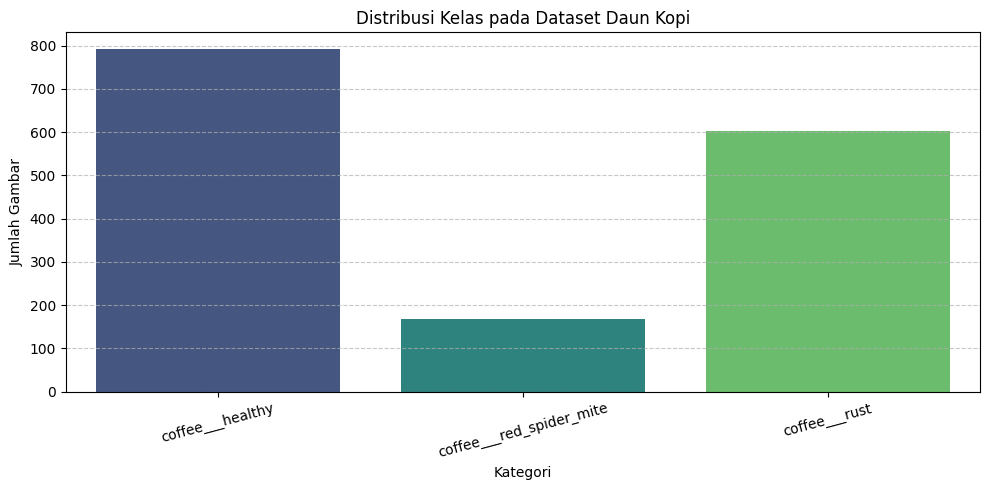

In [ ]:
print("[INFO] Membuat visualisasi dataset...")

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='label', order=classes, palette='viridis')
plt.title('Distribusi Kelas pada Dataset Daun Kopi')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=300)
plt.show()

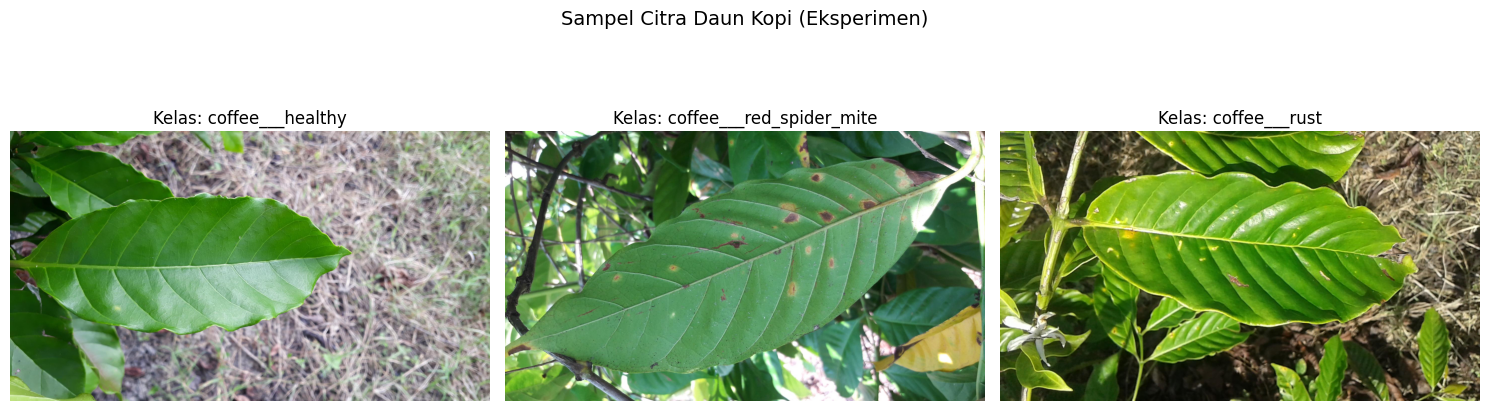

In [ ]:
plt.figure(figsize=(15, 5))
for i, class_name in enumerate(classes):
    sample = df_clean[df_clean['label'] == class_name].sample(1).iloc[0]
    img = cv2.imread(sample['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Kelas: {class_name}")
    plt.axis('off')
plt.suptitle('Sampel Citra Daun Kopi (Eksperimen)', fontsize=14)
plt.tight_layout()
plt.savefig('sampel_dataset.png', dpi=300)
plt.show()

#**5. Pipelining Dataset, Data Loader, & Augmentasi Gambar**

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Augmentasi untuk Data Training
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Transformasi untuk Data Validasi & Testing
val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class CoffeeLeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label_idx']
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = CoffeeLeafDataset(train_df, transform=train_transform)
val_dataset = CoffeeLeafDataset(val_df, transform=val_test_transform)
test_dataset = CoffeeLeafDataset(test_df, transform=val_test_transform)

# PERBAIKAN: num_workers diubah dari 2 menjadi 0 agar hemat System RAM
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("[INFO] DataLoader berhasil diperbarui dengan num_workers=0.")

[INFO] DataLoader berhasil diperbarui dengan num_workers=0.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


#**6. Pendefinisian Arsitektur Model (EfficientNetV2 + CBAM)**

In [ ]:
import timm

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(out))

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class EfficientNetV2_CBAM(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetV2_CBAM, self).__init__()
        self.backbone = timm.create_model('efficientnetv2_rw_s', pretrained=True)
        in_features = self.backbone.num_features

        self.cbam = CBAM(in_planes=in_features)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

num_classes = len(classes)
model = EfficientNetV2_CBAM(num_classes=num_classes).to(device)
print(f"[INFO] Model Arsitektur EfficientNetV2 + CBAM sukses dimuat.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/96.5M [00:00<?, ?B/s]

[INFO] Model Arsitektur EfficientNetV2 + CBAM sukses dimuat.


#**7. Konfigurasi & Proses Training Model Loop**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(dataloader, desc="   Training", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(dataloader, desc=" Validating", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / total, correct / total

EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("--- PROSES PEMBELAJARAN MODEL DIMULAI ---")
for epoch in range(EPOCHS):
    print(f"\n[Epoch {epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] -> "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_coffee_model.pth')
        print("=> [SAVED] Bobot Model Terbaik Tersimpan.")

--- PROSES PEMBELAJARAN MODEL DIMULAI ---

[Epoch 1/10]


Epoch [1/10] -> Train Loss: 1.0285 | Train Acc: 60.10% | Val Loss: 0.8699 | Val Acc: 66.67%
=> [SAVED] Bobot Model Terbaik Tersimpan.

[Epoch 2/10]


Epoch [2/10] -> Train Loss: 0.7231 | Train Acc: 73.16% | Val Loss: 0.5432 | Val Acc: 81.41%
=> [SAVED] Bobot Model Terbaik Tersimpan.

[Epoch 3/10]


Epoch [3/10] -> Train Loss: 0.5288 | Train Acc: 79.09% | Val Loss: 0.4447 | Val Acc: 84.62%
=> [SAVED] Bobot Model Terbaik Tersimpan.

[Epoch 4/10]


Epoch [4/10] -> Train Loss: 0.4604 | Train Acc: 82.77% | Val Loss: 0.4378 | Val Acc: 85.26%
=> [SAVED] Bobot Model Terbaik Tersimpan.

[Epoch 5/10]


...

Epoch [6/10] -> Train Loss: 0.3679 | Train Acc: 85.98% | Val Loss: 0.4027 | Val Acc: 86.54%
=> [SAVED] Bobot Model Terbaik Tersimpan.

[Epoch 7/10]


Epoch [7/10] -> Train Loss: 0.3630 | Train Acc: 86.06% | Val Loss: 0.3960 | Val Acc: 87.82%
=> [SAVED] Bobot Model Terbaik Tersimpan.

[Epoch 8/10]


Epoch [8/10] -> Train Loss: 0.3168 | Train Acc: 88.22% | Val Loss: 0.3961 | Val Acc: 87.18%

[Epoch 9/10]


Epoch [9/10] -> Train Loss: 0.3168 | Train Acc: 87.10% | Val Loss: 0.4019 | Val Acc: 85.90%

[Epoch 10/10]


Epoch [10/10] -> Train Loss: 0.3108 | Train Acc: 88.54% | Val Loss: 0.3933 | Val Acc: 86.54%


#**8. Evaluasi Akhir & Pembuatan Visualisasi Hasil**

--- EVALUASI AKHIR PADA DATA UJI (TEST SET) ---


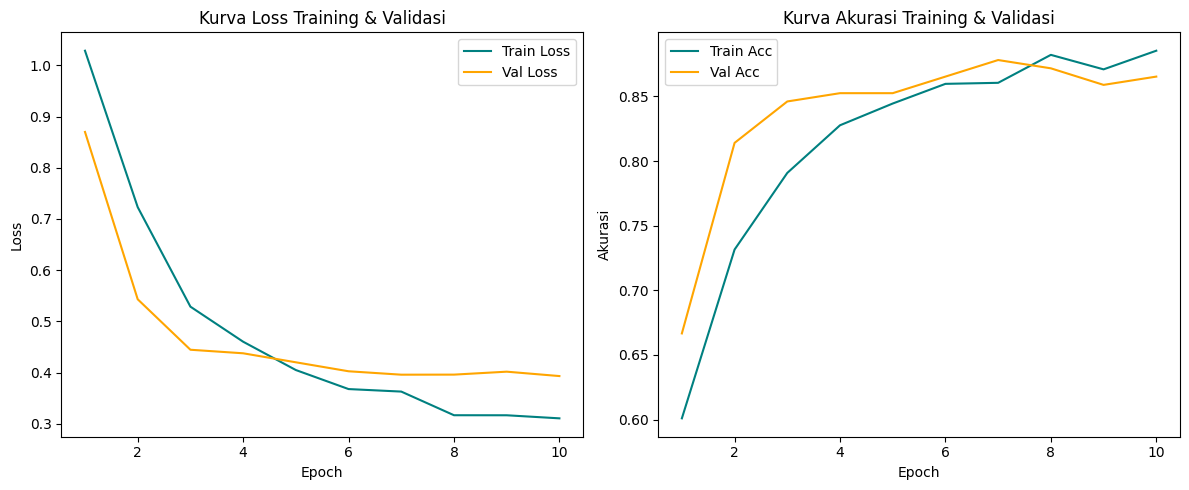

In [ ]:
print("--- EVALUASI AKHIR PADA DATA UJI (TEST SET) ---")
model.load_state_dict(torch.load('best_coffee_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='teal')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
plt.title('Kurva Loss Training & Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='teal')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', color='orange')
plt.title('Kurva Akurasi Training & Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

In [ ]:
print("\n[CLASSIFICATION REPORT SUKSES DICETAK]")
print(classification_report(all_labels, all_preds, target_names=classes))


[CLASSIFICATION REPORT SUKSES DICETAK]
                          precision    recall  f1-score   support

        coffee___healthy       0.94      0.92      0.93        79
coffee___red_spider_mite       0.67      0.24      0.35        17
           coffee___rust       0.78      0.93      0.85        60

                accuracy                           0.85       156
               macro avg       0.79      0.70      0.71       156
            weighted avg       0.85      0.85      0.84       156



In [ ]:
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"Cohen's Kappa Score untuk Validasi Jurnal: {kappa:.4f}\n")

Cohen's Kappa Score untuk Validasi Jurnal: 0.7391



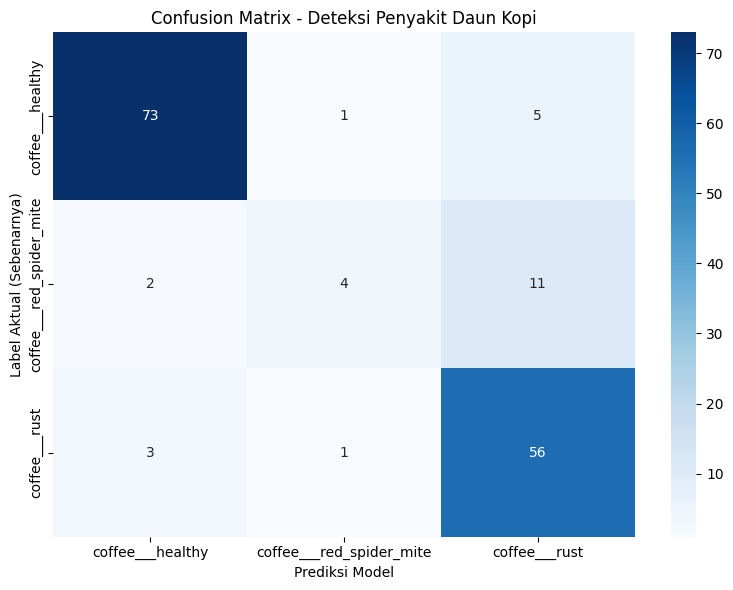


[SELESAI] Seluruh tahapan selesai. File visualisasi hasil riset Anda telah tersimpan di direktori lokal Colab.


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Deteksi Penyakit Daun Kopi')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Aktual (Sebenarnya)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("\n[SELESAI] Seluruh tahapan selesai. File visualisasi hasil riset Anda telah tersimpan di direktori lokal Colab.")